# TPS Over Time Plot

This notebook loads commit TPS data and node-side client receive-rate CSV samples, then plots throughput over time and prints summary metrics for analysis.


In [27]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "axes.facecolor": "#fcfcfd",
    "figure.facecolor": "white",
    "font.size": 12,
})

,view,time,leader_id,executed_slots,elapsed_seconds,tput_measurement,seq,elapsed_from_first_sec
0,1,2026-06-05 10:45:36.465930274-06:00,1,150,0.164381,912.512527,250,0.000000
1,1,2026-06-05 10:45:36.735652675-06:00,1,400,0.434104,921.438822,500,0.269722
2,1,2026-06-05 10:45:37.005442642-06:00,1,650,0.703894,923.434926,750,0.539512
3,1,2026-06-05 10:45:37.273884726-06:00,1,900,0.972336,925.606208,1000,0.807954
4,1,2026-06-05 10:45:37.542512803-06:00,1,1150,1.240964,926.699055,1250,1.076583


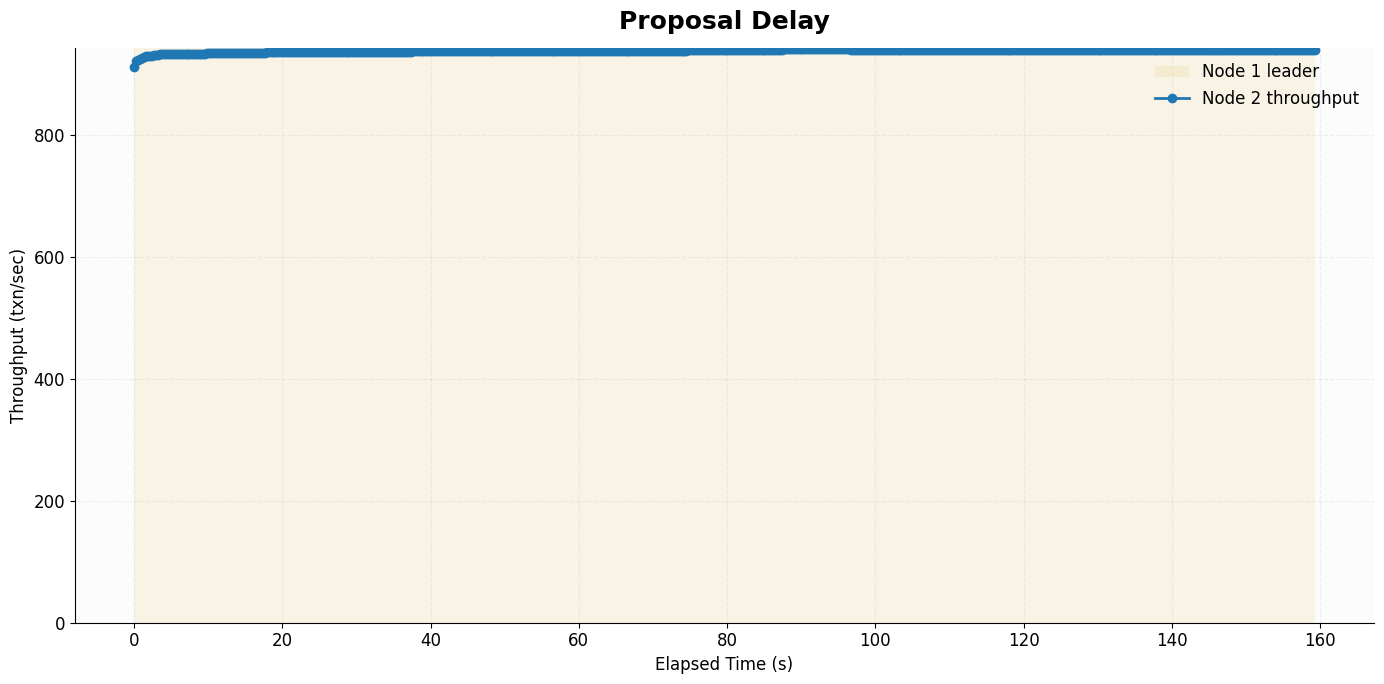

In [30]:
# Change this to pick which node throughput CSV to plot.
node_id = 2

view_start = 70

view_end = 80

throughput_csv_path = Path("logss") / f"node_{node_id}_throughput.csv"
assert throughput_csv_path.exists(), f"Missing file: {throughput_csv_path.resolve()}"

throughput_df = pd.read_csv(throughput_csv_path)
throughput_df["time"] = pd.to_datetime(throughput_df["time"])

throughput_df = throughput_df.sort_values(["time"]).reset_index(drop=True)

# Remove the first 3 seconds of measurements from each view.
throughput_df = throughput_df[throughput_df["elapsed_seconds"] >= 0].copy()
throughput_df = throughput_df.reset_index(drop=True)

# throughput_df = throughput_df[
#     throughput_df["view"].between(view_start, view_end)
# ].copy()
# high_mask = throughput_df["tput_measurement"] > 3000

# high_values = throughput_df.loc[high_mask, "tput_measurement"]

# if len(high_values) > 0:
#     high_min = high_values.min()
#     high_max = high_values.max()

#     if high_min == high_max:
#         throughput_df.loc[high_mask, "tput_measurement"] = 2100
#     else:
#         throughput_df.loc[high_mask, "tput_measurement"] = (
#             1900
#             + (high_values - high_min) / (high_max - high_min) * (1)
#         )



throughput_df["elapsed_from_first_sec"] = (
    throughput_df["time"] - throughput_df["time"].iloc[0]
).dt.total_seconds()

# throughput_df.to_csv(f"logs/node_{node_id}_throughput_cleaned.csv", index=False)

display(throughput_df.head())

fig, ax = plt.subplots(figsize=(14, 7))

leader_colors = {
    1: "#E9C46A",
    2: "#2A9D8F",
    3: "#E76F51",
    4: "#6D597A",
}
leader_change = throughput_df["leader_id"].ne(throughput_df["leader_id"].shift())
segment_id = leader_change.cumsum()
leader_segments = (
    throughput_df.groupby(segment_id)
    .agg(
        leader_id=("leader_id", "first"),
        start_sec=("elapsed_from_first_sec", "first"),
    )
    .reset_index(drop=True)
)
leader_segments["end_sec"] = leader_segments["start_sec"].shift(-1)
leader_segments.loc[leader_segments.index[-1], "end_sec"] = throughput_df[
    "elapsed_from_first_sec"
].iloc[-1]

seen_leaders = set()
for segment in leader_segments.itertuples(index=False):
    leader = int(segment.leader_id)
    label = f"Node {leader} leader" if leader not in seen_leaders else None
    ax.axvspan(
        segment.start_sec,
        segment.end_sec,
        color=leader_colors.get(leader, "#8D99AE"),
        alpha=0.16,
        label=label,
        linewidth=0,
    )
    seen_leaders.add(leader)

ax.plot(
    throughput_df["elapsed_from_first_sec"],
    throughput_df["tput_measurement"],
    marker="o",
    linewidth=2,
    label=f"Node {node_id} throughput",
)

ax.set_title(f"Proposal Delay", fontsize=18, weight="bold", pad=14)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Throughput (txn/sec)")
ax.set_ylim(bottom=0)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [7]:
json_path = Path("check.json")
assert json_path.exists(), f"Missing file: {json_path.resolve()}"

with json_path.open() as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
# df = df[(df["average_tps"] >= 500) & (df["average_tps"] <= 3000)].copy()

df = df.sort_values("elapsed_sec").reset_index(drop=True)
df["window_tps_smooth"] = df["window_tps"].rolling(window=10, min_periods=1).mean()

change_mask = df["committed_total"].ne(df["committed_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    plot_df = df.loc[:last_change_idx].copy()
else:
    plot_df = df.copy()

summary = {
    "samples": int(len(df)),
    "plot_samples": int(len(plot_df)),
    "final_committed": int(df["committed_total"].max()),
    "peak_window_tps": float(plot_df["window_tps"].max()),
    "peak_smoothed_tps": float(plot_df["window_tps_smooth"].max()),
    "final_average_tps": float(plot_df["average_tps"].iloc[-1]),
    "elapsed_sec": float(plot_df["elapsed_sec"].iloc[-1]),
}

pd.Series(summary)

samples                981.000000
plot_samples           529.000000
final_committed      19620.000000
peak_window_tps        235.003966
peak_smoothed_tps      200.004230
final_average_tps      185.448077
elapsed_sec            105.797808
dtype: float64

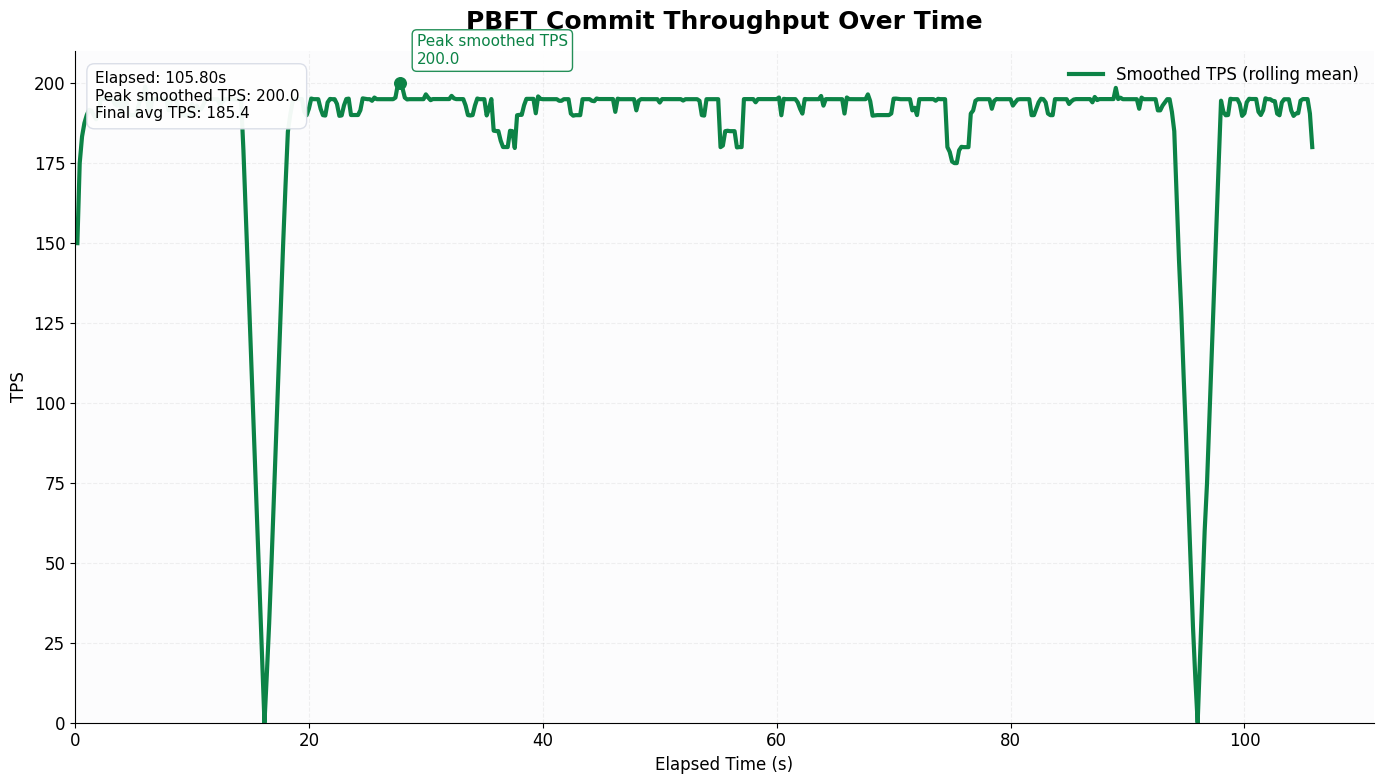

In [8]:
fig, ax1 = plt.subplots()

throughput_color = "#145DA0"
smooth_color = "#0C8346"

# ax1.plot(
#     plot_df["elapsed_sec"],
#     plot_df["window_tps"],
#     color=throughput_color,
#     linewidth=2.0,
#     alpha=0.35,
#     label="Window TPS",
# )
ax1.plot(
    plot_df["elapsed_sec"],
    plot_df["window_tps_smooth"],
    color=smooth_color,
    linewidth=3.0,
    label="Smoothed TPS (rolling mean)",
)

peak_idx = plot_df["window_tps_smooth"].idxmax()
peak_x = plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = plot_df.loc[peak_idx, "window_tps_smooth"]
ax1.scatter([peak_x], [peak_y], color=smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed TPS\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=smooth_color, alpha=0.9),
)

ax1.set_title("PBFT Commit Throughput Over Time", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("TPS")

ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

summary_text = (
    f"Elapsed: {summary['elapsed_sec']:.2f}s\n"
    
    f"Peak smoothed TPS: {summary['peak_smoothed_tps']:.1f}\n"
    f"Final avg TPS: {summary['final_average_tps']:.1f}"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

ax1.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


In [32]:
output_path = Path("tps_graph_pretty.png")
fig.savefig(output_path, dpi=220, bbox_inches="tight")
output_path.resolve()

PosixPath('/Users/hamzakhawaja/Documents/github/pbftm/tps_graph_pretty.png')

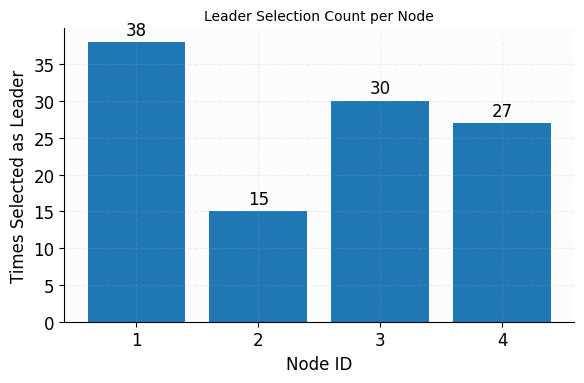

In [71]:
import matplotlib.pyplot as plt

leader_counts = {
    1: 38,
    2: 15,
    3: 30,
    4: 27,
}
# 1,42; 2,6; 3,28; 4,23

nodes = list(leader_counts.keys())
counts = list(leader_counts.values())

plt.figure(figsize=(6, 4))
plt.bar(nodes, counts)

plt.title("Leader Selection Count per Node", fontsize=10)
plt.xlabel("Node ID")
plt.ylabel("Times Selected as Leader")
plt.xticks(nodes)
plt.ylim(bottom=0)

for node, count in zip(nodes, counts):
    plt.text(node, count + 0.5, str(count), ha="center", va="bottom")

plt.tight_layout()
plt.show()


## Node Client Receive Rate

This section loads the node-side CSV written by `clientReceiveRateLogger` and summarizes receive TPS over time.


In [32]:
# Change this to pick which node receive-rate CSV to plot.
receive_node_id = 1
receive_rate_csv_path = Path("logss") / f"node_{receive_node_id}_client_receive_rate.csv"
assert receive_rate_csv_path.exists(), f"Missing file: {receive_rate_csv_path.resolve()}"

receive_df = pd.read_csv(receive_rate_csv_path)
receive_df["timestamp"] = pd.to_datetime(receive_df["timestamp"])
receive_df = receive_df.sort_values("elapsed_sec").reset_index(drop=True)

# Trim idle samples after the node stops receiving new client transactions.
change_mask = receive_df["received_total"].ne(receive_df["received_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    receive_plot_df = receive_df.loc[:last_change_idx].copy()
else:
    receive_plot_df = receive_df.copy()

receive_plot_df["window_tps_smooth"] = (
    receive_plot_df["window_tps"].rolling(window=5, min_periods=1).mean()
)

active_receive_df = receive_plot_df[receive_plot_df["received_delta"] > 0].copy()
if active_receive_df.empty:
    active_receive_df = receive_plot_df.copy()

receive_summary = {
    "samples": int(len(receive_df)),
    "plot_samples": int(len(receive_plot_df)),
    "active_samples": int(len(active_receive_df)),
    "final_received": int(receive_plot_df["received_total"].iloc[-1]),
    "elapsed_sec": float(receive_plot_df["elapsed_sec"].iloc[-1]),
    "mean_window_tps_active": float(active_receive_df["window_tps"].mean()),
    "median_window_tps_active": float(active_receive_df["window_tps"].median()),
    "p95_window_tps_active": float(active_receive_df["window_tps"].quantile(0.95)),
    "peak_window_tps": float(receive_plot_df["window_tps"].max()),
    "peak_smoothed_tps": float(receive_plot_df["window_tps_smooth"].max()),
    "final_average_tps": float(receive_plot_df["average_tps"].iloc[-1]),
}

display(pd.Series(receive_summary))
display(receive_plot_df.head())


samples                        219.000000
plot_samples                    96.000000
active_samples                  91.000000
final_received              150000.000000
elapsed_sec                     95.999748
mean_window_tps_active        1648.351591
median_window_tps_active      1699.997744
p95_window_tps_active         1700.004695
peak_window_tps               1700.005942
peak_smoothed_tps             1680.000047
final_average_tps             1562.504104
dtype: float64

,timestamp_unix_nano,timestamp,elapsed_sec,received_total,received_delta,window_sec,window_tps,average_tps,window_tps_smooth
0,1780677932108270454,2026-06-05 10:45:32.108270454-06:00,0.999753,0,0,0.999753,0.0,0.0,0.0
1,1780677933108270288,2026-06-05 10:45:33.108270288-06:00,1.999752,0,0,1.000000,0.0,0.0,0.0
2,1780677934108267611,2026-06-05 10:45:34.108267611-06:00,2.999750,0,0,0.999997,0.0,0.0,0.0
3,1780677935108267304,2026-06-05 10:45:35.108267304-06:00,3.999749,0,0,1.000000,0.0,0.0,0.0
4,1780677936108267928,2026-06-05 10:45:36.108267928-06:00,4.999750,0,0,1.000001,0.0,0.0,0.0


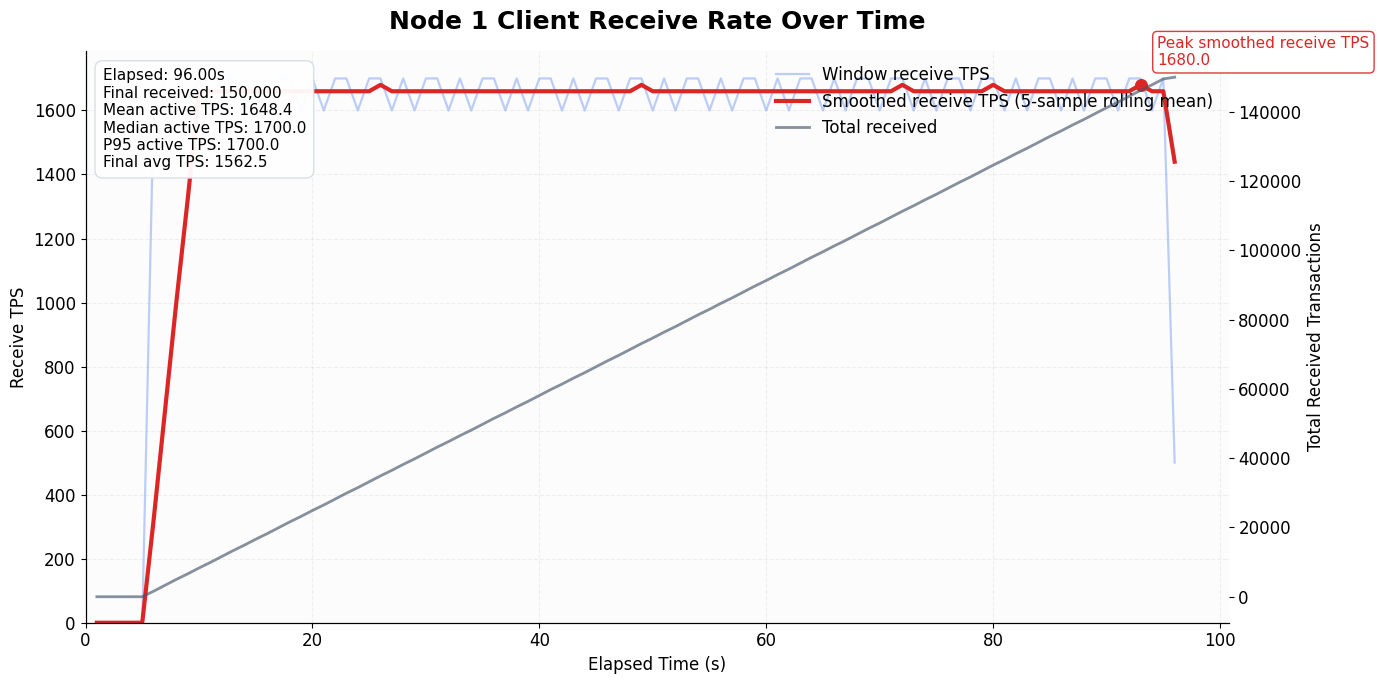

In [33]:
fig, ax1 = plt.subplots(figsize=(14, 7))

receive_color = "#2563EB"
receive_smooth_color = "#DC2626"
total_color = "#475569"

ax1.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["window_tps"],
    color=receive_color,
    linewidth=1.6,
    alpha=0.30,
    label="Window receive TPS",
)
ax1.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["window_tps_smooth"],
    color=receive_smooth_color,
    linewidth=3.0,
    label="Smoothed receive TPS (5-sample rolling mean)",
)

peak_idx = receive_plot_df["window_tps_smooth"].idxmax()
peak_x = receive_plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = receive_plot_df.loc[peak_idx, "window_tps_smooth"]
ax1.scatter([peak_x], [peak_y], color=receive_smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed receive TPS\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=receive_smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=receive_smooth_color, alpha=0.9),
)

ax1.set_title(f"Node {receive_node_id} Client Receive Rate Over Time", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("Receive TPS")
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["received_total"],
    color=total_color,
    linewidth=2.0,
    alpha=0.65,
    label="Total received",
)
ax2.set_ylabel("Total Received Transactions")
ax2.grid(False)

summary_text = (
    f"Elapsed: {receive_summary['elapsed_sec']:.2f}s\n"
    f"Final received: {receive_summary['final_received']:,}\n"
    f"Mean active TPS: {receive_summary['mean_window_tps_active']:.1f}\n"
    f"Median active TPS: {receive_summary['median_window_tps_active']:.1f}\n"
    f"P95 active TPS: {receive_summary['p95_window_tps_active']:.1f}\n"
    f"Final avg TPS: {receive_summary['final_average_tps']:.1f}"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
receive_output_path = Path(f"node_{receive_node_id}_client_receive_rate.png")
fig.savefig(receive_output_path, dpi=220, bbox_inches="tight")
receive_output_path.resolve()


In [90]:
tput = 180
num = 0
while tput < 200:
    tput = tput*1.01
    num += 1
print(num)


11
